In [13]:
import geopandas as gpd

gdf = gpd.read_file("../data/landmark_raw/LandMark_IPLC_pt_public_v202509.shp")

gdf.head()

,name,identity,form_rec,doc_status,stat_date,stat_note,country,iso_code,category,ethncty_1,...,data_ctrb,data_src,data_src_s,data_src_l,data_date,add_note,more_info,layer,download,geometry
0,Taquaritiua,Indigenous,Acknowledged by govt,Not documented,NaN,Em Estudo,Brazil,BRA,Terra IndÃ­gena Tradicionalmente Ocupada,Gamela,...,Publicly available,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,FUNAI,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,2023/10/06,NaN,https://www.gov.br/funai/pt-br,Indigenous Lands,Yes,POINT (-5029304.202 -358598.883)
1,Vitoi KuÃª,Indigenous,Acknowledged by govt,Not documented,NaN,Em Estudo,Brazil,BRA,Terra IndÃ­gena Tradicionalmente Ocupada,GuaranÃ­,...,Publicly available,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,FUNAI,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,2023/10/06,NaN,https://www.gov.br/funai/pt-br,Indigenous Lands,Yes,POINT (-6050982.429 -2747755.086)
2,Dourados-AmambaipeguÃ¡ II,Indigenous,Acknowledged by govt,Not documented,NaN,Em Estudo,Brazil,BRA,Terra IndÃ­gena Tradicionalmente Ocupada,GuaranÃ­,...,Publicly available,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,FUNAI,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,2023/10/06,NaN,https://www.gov.br/funai/pt-br,Indigenous Lands,Yes,POINT (-6040648.27 -2640527.156)
3,Laguna Piru (Nhandeva PeguÃ¡),Indigenous,Acknowledged by govt,Not documented,NaN,Em Estudo,Brazil,BRA,Terra IndÃ­gena Tradicionalmente Ocupada,GuaranÃ­,...,Publicly available,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,FUNAI,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,2023/10/06,NaN,https://www.gov.br/funai/pt-br,Indigenous Lands,Yes,POINT (-6040061.987 -2705956.412)
4,Laranjeira Nhanderu (BrilhantepeguÃ¡),Indigenous,Acknowledged by govt,Not documented,NaN,Em Estudo,Brazil,BRA,Terra IndÃ­gena Tradicionalmente Ocupada,Guarani KaiowÃ¡,...,Publicly available,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,FUNAI,FundaÃ§Ã£o Nacional dos Povos IndÃ­genas - FUNAI,2023/10/06,NaN,https://www.gov.br/funai/pt-br,Indigenous Lands,Yes,POINT (-6073090.48 -2496056.267)


In [14]:
gdf.shape


(2646, 27)

In [15]:
gdf["country"].unique()


<StringArray>
[                  'Brazil',                 'Cambodia',
              'Afghanistan',                 'Paraguay',
                    'PerÃº', 'United States of America']
Length: 6, dtype: str

In [16]:
gdf["country"] = gdf["country"].str.replace("PerÃº", "Peru")

In [17]:
gdf["country"].unique()


<StringArray>
[                  'Brazil',                 'Cambodia',
              'Afghanistan',                 'Paraguay',
                     'Peru', 'United States of America']
Length: 6, dtype: str

In [18]:
gdf["country"].value_counts()

country
Peru                        2014
United States of America     227
Paraguay                     183
Brazil                       131
Cambodia                      90
Afghanistan                    1
Name: count, dtype: int64

In [19]:
gdf.groupby("country")["area_gis"].sum().sort_values(ascending=False)

country
Paraguay                    26827.805758
Afghanistan                     0.000000
Brazil                          0.000000
Cambodia                        0.000000
Peru                            0.000000
United States of America        0.000000
Name: area_gis, dtype: float64

In [20]:
gdf[["area_ofcl", "area_gis"]].describe()

,area_ofcl,area_gis
count,2646.000000,2646.000000
mean,8.354795,10.139004
std,86.961664,93.332427
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1496.312700,3016.592248


In [21]:
gdf["form_rec"].value_counts()


form_rec
Not acknowledged by govt    1569
Acknowledged by govt        1077
Name: count, dtype: int64

In [23]:
import pandas as pd

In [24]:
pd.crosstab(gdf["country"], gdf["form_rec"])


form_rec,Acknowledged by govt,Not acknowledged by govt
country,,
Afghanistan,0,1
Brazil,131,0
Cambodia,90,0
Paraguay,183,0
Peru,446,1568
United States of America,227,0


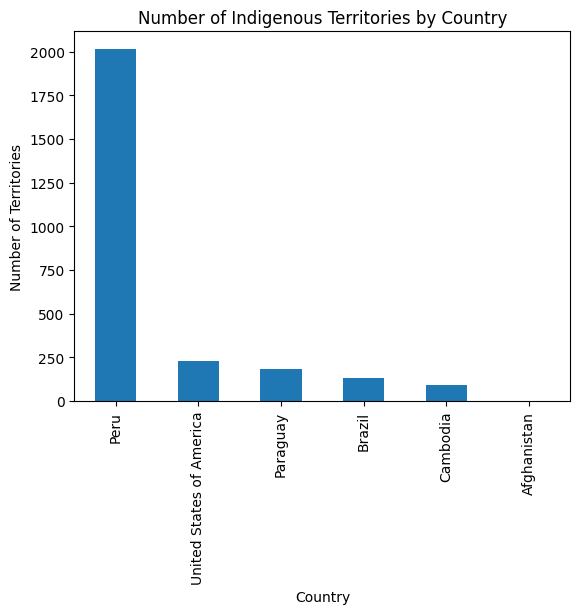

In [25]:
import matplotlib.pyplot as plt

gdf["country"].value_counts().plot(kind="bar")

plt.title("Number of Indigenous Territories by Country")
plt.xlabel("Country")
plt.ylabel("Number of Territories")
plt.show()

In [27]:
gdf.columns


Index(['name', 'identity', 'form_rec', 'doc_status', 'stat_date', 'stat_note',
       'country', 'iso_code', 'category', 'ethncty_1', 'populatn',
       'pop_source', 'pop_year', 'area_ofcl', 'area_gis', 'scale', 'method',
       'data_ctrb', 'data_src', 'data_src_s', 'data_src_l', 'data_date',
       'add_note', 'more_info', 'layer', 'download', 'geometry'],
      dtype='str')

In [28]:
landmark_country_summary = gdf.groupby("country").agg(
    territories=("country", "count"),
    recognized=("form_rec", lambda x: (x == "Acknowledged by govt").sum()),
    not_recognized=("form_rec", lambda x: (x == "Not acknowledged by govt").sum())
).reset_index()

landmark_country_summary

,country,territories,recognized,not_recognized
0,Afghanistan,1,0,1
1,Brazil,131,131,0
2,Cambodia,90,90,0
3,Paraguay,183,183,0
4,Peru,2014,446,1568
5,United States of America,227,227,0


In [29]:
landmark_country_summary.to_csv("../data/processed/landmark_country_summary.csv", index=False)